In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
path=r'C:\Users\yaswa\OneDrive\Desktop\artificial intelligence project\data\final_processed_data.csv'
df = pd.read_csv(path)
df

,Unnamed: 0,match_obj_id,inningNumber,oversActual,pitchLine,pitchLength,isFour,isSix,isWicket,byes,...,Batsman_Role,Full Name,Batsman_Batting_Style,Batsman_Playing_Role,Bowler_Name,Bowler_Role,Full Name_bowler,Batting Style (s)_bowler,Bowler_Bowling_Style,Bowler_Playing_Role
0,0,1273712,1,0.1,ON_THE_STUMPS,GOOD_LENGTH,False,False,False,0,...,P,Tony Ura,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,left-arm medium-fast,bowler
1,1,1273712,1,0.2,ON_THE_STUMPS,SHORT_OF_A_GOOD_LENGTH,False,False,False,0,...,P,Tony Ura,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,left-arm medium-fast,bowler
2,2,1273712,1,0.3,ON_THE_STUMPS,GOOD_LENGTH,False,False,False,0,...,P,Tony Ura,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,left-arm medium-fast,bowler
3,3,1273712,1,0.4,ON_THE_STUMPS,GOOD_LENGTH,False,False,False,0,...,P,Tony Ura,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,left-arm medium-fast,bowler
4,4,1273712,1,0.5,ON_THE_STUMPS,GOOD_LENGTH,False,False,True,0,...,P,Tony Ura,right-hand bat,opening batter,Bilal Khan,P,Bilal Khan,lhb,left-arm medium-fast,bowler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33024,60321,951373,2,8.3,OUTSIDE_OFFSTUMP,GOOD_LENGTH,False,False,False,0,...,P,Marlon Samuels,right-hand bat,top-order batter,LE Plunkett,P,Liam Plunkett,rhb,right-arm fast,bowler
33025,60322,951373,2,8.4,DOWN_LEG,SHORT_OF_A_GOOD_LENGTH,False,False,False,0,...,P,Dwayne Bravo,right-hand bat,allrounder,LE Plunkett,P,Liam Plunkett,rhb,right-arm fast,bowler
33026,60323,951373,2,8.4,OUTSIDE_OFFSTUMP,SHORT_OF_A_GOOD_LENGTH,False,False,False,0,...,P,Dwayne Bravo,right-hand bat,allrounder,LE Plunkett,P,Liam Plunkett,rhb,right-arm fast,bowler
33027,60324,951373,2,8.5,OUTSIDE_OFFSTUMP,GOOD_LENGTH,False,False,False,0,...,P,Dwayne Bravo,right-hand bat,allrounder,LE Plunkett,P,Liam Plunkett,rhb,right-arm fast,bowler


In [4]:
df.shape

(33029, 30)

In [5]:
def calculate_batsman_metrics(group):
    runs_scored = group['run'].sum()
    legal_deliveries = group[(group['wides'] == 0) & (group['noballs'] == 0)]
    balls_faced = len(legal_deliveries)
    wickets_lost = group['isWicket'].sum()
    boundaries = group['isFour'].sum() + group['isSix'].sum()
    strike_rate = (runs_scored / balls_faced) * 100 if balls_faced > 0 else 0
    dismissal_rate = balls_faced / wickets_lost if wickets_lost > 0 else np.inf
    boundary_percentage = (boundaries / balls_faced) * 100 if balls_faced > 0 else 0
    average= runs_scored/wickets_lost if wickets_lost > 0 else np.inf
    return pd.Series({
        'Run_Scored':runs_scored,
        'Balls_Faced': balls_faced,
        'Strike_Rate': strike_rate,
        'Dismissals':wickets_lost,
        'Dismissal_Rate': dismissal_rate,
        'Boundary_percentage':boundary_percentage,
        'Average':average
    })

In [6]:
batsman_metrics_overall = df.groupby(['Full Name']).apply(calculate_batsman_metrics).reset_index()
batsman_metrics_overall.head()

C:\Users\yaswa\AppData\Local\Temp\ipykernel_14544\3507725156.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  batsman_metrics_overall = df.groupby(['Full Name']).apply(calculate_batsman_metrics).reset_index()


,Full Name,Run_Scored,Balls_Faced,Strike_Rate,Dismissals,Dismissal_Rate,Boundary_percentage,Average
0,AB de Villiers,117.0,61.0,191.803279,3.0,20.333333,22.950820,39.000000
1,Aamir Kaleem,0.0,5.0,0.000000,2.0,2.500000,0.000000,0.000000
2,Aaron Finch,333.0,258.0,129.069767,11.0,23.454545,13.953488,30.272727
3,Aaron Johnson,101.0,73.0,138.356164,4.0,18.250000,21.917808,25.250000
4,Aaron Jones,152.0,87.0,174.712644,1.0,87.000000,21.839080,152.000000


In [7]:
df.columns

Index(['Unnamed: 0', 'match_obj_id', 'inningNumber', 'oversActual',
       'pitchLine', 'pitchLength', 'isFour', 'isSix', 'isWicket', 'byes',
       'legbyes', 'wides', 'noballs', 'run', 'totalRuns', 'totalWickets',
       'shotType', 'time_of_day', 'Ground Name', 'Batsman_Name',
       'Batsman_Role', 'Full Name', 'Batsman_Batting_Style',
       'Batsman_Playing_Role', 'Bowler_Name', 'Bowler_Role',
       'Full Name_bowler', 'Batting Style (s)_bowler', 'Bowler_Bowling_Style',
       'Bowler_Playing_Role'],
      dtype='object')

In [8]:
batsmen_metrics=df.groupby(['Full Name','pitchLength','pitchLine']).apply(calculate_batsman_metrics).reset_index()
batsmen_metrics.head()

C:\Users\yaswa\AppData\Local\Temp\ipykernel_14544\741080997.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  batsmen_metrics=df.groupby(['Full Name','pitchLength','pitchLine']).apply(calculate_batsman_metrics).reset_index()


,Full Name,pitchLength,pitchLine,Run_Scored,Balls_Faced,Strike_Rate,Dismissals,Dismissal_Rate,Boundary_percentage,Average
0,AB de Villiers,FULL,DOWN_LEG,2.0,1.0,200.0,0.0,inf,0.0,inf
1,AB de Villiers,FULL,ON_THE_STUMPS,4.0,4.0,100.0,0.0,inf,0.0,inf
2,AB de Villiers,FULL,OUTSIDE_OFFSTUMP,6.0,1.0,600.0,0.0,inf,100.0,inf
3,AB de Villiers,FULL,WIDE_DOWN_LEG,1.0,0.0,0.0,0.0,inf,0.0,inf
4,AB de Villiers,FULL_TOSS,ON_THE_STUMPS,6.0,1.0,600.0,0.0,inf,100.0,inf


In [9]:
batsmen_metrics['Feature'] = batsmen_metrics['pitchLength'] + '_' + batsmen_metrics['pitchLine']

In [10]:
batsmen_metrics.head()

,Full Name,pitchLength,pitchLine,Run_Scored,Balls_Faced,Strike_Rate,Dismissals,Dismissal_Rate,Boundary_percentage,Average,Feature
0,AB de Villiers,FULL,DOWN_LEG,2.0,1.0,200.0,0.0,inf,0.0,inf,FULL_DOWN_LEG
1,AB de Villiers,FULL,ON_THE_STUMPS,4.0,4.0,100.0,0.0,inf,0.0,inf,FULL_ON_THE_STUMPS
2,AB de Villiers,FULL,OUTSIDE_OFFSTUMP,6.0,1.0,600.0,0.0,inf,100.0,inf,FULL_OUTSIDE_OFFSTUMP
3,AB de Villiers,FULL,WIDE_DOWN_LEG,1.0,0.0,0.0,0.0,inf,0.0,inf,FULL_WIDE_DOWN_LEG
4,AB de Villiers,FULL_TOSS,ON_THE_STUMPS,6.0,1.0,600.0,0.0,inf,100.0,inf,FULL_TOSS_ON_THE_STUMPS


In [11]:
player_profiles = batsmen_metrics.pivot_table(
    index='Full Name', 
    columns='Feature', 
    values=['Strike_Rate', 'Dismissal_Rate', 'Boundary_percentage', 'Balls_Faced']
).reset_index()

In [12]:
player_profiles

Full Name   Balls_Faced                     \
Feature                  FULL_DOWN_LEG FULL_ON_THE_STUMPS   
0         AB de Villiers           1.0                4.0   
1           Aamir Kaleem           NaN                NaN   
2            Aaron Finch           4.0                8.0   
3          Aaron Johnson           NaN                7.0   
4            Aaron Jones           2.0                7.0   
..                   ...           ...                ...   
457         Yuvraj Singh           2.0                2.0   
458          Zahoor Khan           NaN                NaN   
459           Zane Green           0.0               14.0   
460          Zawar Farid           NaN                NaN   
461      Zeeshan Maqsood           3.0               13.0   

                                                                          \
Feature FULL_OUTSIDE_OFFSTUMP FULL_TOSS_DOWN_LEG FULL_TOSS_ON_THE_STUMPS   
0                         1.0                NaN                     1.0   
1                         1.0                NaN                     NaN   
2                        22.0                NaN                     2.0   
3                         6.0                NaN                     1.0   
4                         7.0                NaN                     2.0   
..                        ...                ...                     ...   
457                       2.0                NaN                     NaN   
458                       NaN                NaN                     NaN   
459                      14.0                NaN                     1.0   
460                       1.0                NaN                     NaN   
461                      13.0                NaN                     3.0   

                                                            \
Feature FULL_TOSS_OUTSIDE_OFFSTUMP FULL_TOSS_WIDE_DOWN_LEG   
0                              2.0                     NaN   
1                              NaN                     NaN   
2                              4.0                     NaN   
3                              1.0                     NaN   
4                              1.0                     NaN   
..                             ...                     ...   
457                            1.0                     NaN   
458                            1.0                     NaN   
459                            1.0                     NaN   
460                            NaN                     NaN   
461                            NaN                     NaN   

                                                            ...  \
Feature FULL_TOSS_WIDE_OUTSIDE_OFFSTUMP FULL_WIDE_DOWN_LEG  ...   
0                                   1.0                0.0  ...   
1                                   NaN                NaN  ...   
2                                   1.0                0.0  ...   
3                                   NaN                NaN  ...   
4                                   2.0                NaN  ...   
..                                  ...                ...  ...   
457                                 NaN                NaN  ...   
458                                 NaN                NaN  ...   
459                                 1.0                NaN  ...   
460                                 NaN                NaN  ...   
461                                 1.0                NaN  ...   

                                         Strike_Rate                      \
Feature SHORT_OF_A_GOOD_LENGTH_WIDE_OUTSIDE_OFFSTUMP SHORT_ON_THE_STUMPS   
0                                              100.0                 NaN   
1                                                NaN                 0.0   
2                                                0.0                50.0   
3                                                0.0                50.0   
4                                                NaN               300.0   
..                   

In [13]:
player_profiles.columns = [
    '_'.join(map(str, col)).strip() if col[0] != 'Full Name' else col[0] 
    for col in player_profiles.columns.values
]

In [14]:
player_profiles.head()

,Full Name,Balls_Faced_FULL_DOWN_LEG,Balls_Faced_FULL_ON_THE_STUMPS,Balls_Faced_FULL_OUTSIDE_OFFSTUMP,Balls_Faced_FULL_TOSS_DOWN_LEG,Balls_Faced_FULL_TOSS_ON_THE_STUMPS,Balls_Faced_FULL_TOSS_OUTSIDE_OFFSTUMP,Balls_Faced_FULL_TOSS_WIDE_DOWN_LEG,Balls_Faced_FULL_TOSS_WIDE_OUTSIDE_OFFSTUMP,Balls_Faced_FULL_WIDE_DOWN_LEG,...,Strike_Rate_SHORT_OF_A_GOOD_LENGTH_WIDE_OUTSIDE_OFFSTUMP,Strike_Rate_SHORT_ON_THE_STUMPS,Strike_Rate_SHORT_OUTSIDE_OFFSTUMP,Strike_Rate_SHORT_WIDE_DOWN_LEG,Strike_Rate_SHORT_WIDE_OUTSIDE_OFFSTUMP,Strike_Rate_YORKER_DOWN_LEG,Strike_Rate_YORKER_ON_THE_STUMPS,Strike_Rate_YORKER_OUTSIDE_OFFSTUMP,Strike_Rate_YORKER_WIDE_DOWN_LEG,Strike_Rate_YORKER_WIDE_OUTSIDE_OFFSTUMP
0,AB de Villiers,1.0,4.0,1.0,NaN,1.0,2.0,NaN,1.0,0.0,...,100.0,NaN,350.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aamir Kaleem,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aaron Finch,4.0,8.0,22.0,NaN,2.0,4.0,NaN,1.0,0.0,...,0.0,50.0,138.461538,NaN,500.0,NaN,100.000000,100.0,NaN,100.0
3,Aaron Johnson,NaN,7.0,6.0,NaN,1.0,1.0,NaN,NaN,NaN,...,0.0,50.0,300.000000,NaN,NaN,NaN,400.000000,NaN,NaN,NaN
4,Aaron Jones,2.0,7.0,7.0,NaN,2.0,1.0,NaN,2.0,NaN,...,NaN,300.0,66.666667,NaN,NaN,NaN,83.333333,0.0,NaN,NaN


In [15]:
total_balls = player_profiles.filter(like='Balls_Faced_').sum(axis=1)
player_profiles['Total_Balls'] = total_balls
MIN_BALLS_THRESHOLD = 150
final_profiles_df = player_profiles[player_profiles['Total_Balls'] >= MIN_BALLS_THRESHOLD]
final_profiles_df.head()

,Full Name,Balls_Faced_FULL_DOWN_LEG,Balls_Faced_FULL_ON_THE_STUMPS,Balls_Faced_FULL_OUTSIDE_OFFSTUMP,Balls_Faced_FULL_TOSS_DOWN_LEG,Balls_Faced_FULL_TOSS_ON_THE_STUMPS,Balls_Faced_FULL_TOSS_OUTSIDE_OFFSTUMP,Balls_Faced_FULL_TOSS_WIDE_DOWN_LEG,Balls_Faced_FULL_TOSS_WIDE_OUTSIDE_OFFSTUMP,Balls_Faced_FULL_WIDE_DOWN_LEG,...,Strike_Rate_SHORT_ON_THE_STUMPS,Strike_Rate_SHORT_OUTSIDE_OFFSTUMP,Strike_Rate_SHORT_WIDE_DOWN_LEG,Strike_Rate_SHORT_WIDE_OUTSIDE_OFFSTUMP,Strike_Rate_YORKER_DOWN_LEG,Strike_Rate_YORKER_ON_THE_STUMPS,Strike_Rate_YORKER_OUTSIDE_OFFSTUMP,Strike_Rate_YORKER_WIDE_DOWN_LEG,Strike_Rate_YORKER_WIDE_OUTSIDE_OFFSTUMP,Total_Balls
2,Aaron Finch,4.0,8.0,22.0,NaN,2.0,4.0,NaN,1.0,0.0,...,50.0,138.461538,NaN,500.0,NaN,100.000000,100.000000,NaN,100.0,258.0
14,Aiden Markram,2.0,17.0,27.0,2.0,1.0,NaN,NaN,NaN,NaN,...,400.0,160.000000,NaN,0.0,100.0,50.000000,66.666667,NaN,NaN,214.0
22,Alex Hales,4.0,13.0,19.0,2.0,4.0,1.0,NaN,NaN,NaN,...,0.0,125.000000,NaN,NaN,50.0,66.666667,NaN,NaN,NaN,202.0
32,Andy Balbirnie,3.0,23.0,22.0,NaN,1.0,3.0,NaN,1.0,NaN,...,500.0,150.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,222.0
43,Asghar Afghan,2.0,17.0,16.0,1.0,7.0,3.0,NaN,8.0,NaN,...,0.0,166.666667,NaN,50.0,NaN,0.000000,100.000000,NaN,100.0,156.0


In [16]:
batsman_bowling_matrix = pd.pivot_table(
    data=df,
    values='run',
    index='Full Name',
    columns='pitchLength', 
    aggfunc='mean'
).fillna(0)

In [17]:
batsman_bowling_matrix

pitchLength,FULL,FULL_TOSS,GOOD_LENGTH,SHORT,SHORT_OF_A_GOOD_LENGTH,YORKER
Full Name,,,,,,
AB de Villiers,1.625000,3.750000,1.595745,2.333333,2.333333,0.000
Aamir Kaleem,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
Aaron Finch,2.225000,2.250000,1.018182,1.238095,0.893617,0.800
Aaron Johnson,2.461538,2.000000,1.000000,2.000000,0.538462,4.000
Aaron Jones,1.888889,3.200000,1.897436,1.333333,0.882353,0.625
...,...,...,...,...,...,...
Yuvraj Singh,0.833333,6.000000,0.892857,1.285714,0.923077,0.000
Zahoor Khan,0.000000,1.000000,0.000000,0.000000,0.000000,0.000
Zane Green,1.066667,0.666667,0.800000,0.500000,0.810811,0.400


In [18]:
scaler = MinMaxScaler()
batsman_scaled = pd.DataFrame(
    scaler.fit_transform(batsman_bowling_matrix),
    index=batsman_bowling_matrix.index,
    columns=batsman_bowling_matrix.columns
)


In [19]:
batsman_scaled.head()

pitchLength,FULL,FULL_TOSS,GOOD_LENGTH,SHORT,SHORT_OF_A_GOOD_LENGTH,YORKER
Full Name,,,,,,
AB de Villiers,0.270833,0.625000,0.398936,0.388889,0.388889,0.00000
Aamir Kaleem,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
Aaron Finch,0.370833,0.375000,0.254545,0.206349,0.148936,0.20000
Aaron Johnson,0.410256,0.333333,0.250000,0.333333,0.089744,1.00000
Aaron Jones,0.314815,0.533333,0.474359,0.222222,0.147059,0.15625


In [20]:
similarity_matrix = cosine_similarity(batsman_scaled)
similar_df = pd.DataFrame(similarity_matrix, index=batsman_scaled.index, columns=batsman_scaled.index)

In [21]:
similar_df.head()

Full Name,AB de Villiers,Aamir Kaleem,Aaron Finch,Aaron Johnson,Aaron Jones,Aaron Phangiso,Aasif Sheikh,Aayan Afzal Khan,Abinash Bohara,Adam Milne,...,Wesley Barresi,Wessly Madhevere,Will Jacks,William Porterfield,Yasir Ali,Yuvraj Singh,Zahoor Khan,Zane Green,Zawar Farid,Zeeshan Maqsood
Full Name,,,,,,,,,,,,,,,,,,,,,
AB de Villiers,1.000000,0.0,0.892492,0.501935,0.930898,0.578469,0.281509,0.705178,0.0,0.404217,...,0.679905,0.987639,0.787398,0.744544,0.467737,0.871612,0.649635,0.850164,0.437231,0.903504
Aamir Kaleem,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aaron Finch,0.892492,0.0,1.000000,0.770200,0.955633,0.432217,0.554225,0.591246,0.0,0.222591,...,0.653290,0.863504,0.844442,0.687132,0.576935,0.770945,0.560453,0.934433,0.665847,0.814177
Aaron Johnson,0.501935,0.0,0.770200,1.000000,0.659679,0.203908,0.339404,0.394652,0.0,0.074245,...,0.359652,0.492825,0.459147,0.401283,0.316070,0.411945,0.275766,0.718697,0.396067,0.494866
Aaron Jones,0.930898,0.0,0.955633,0.659679,1.000000,0.538996,0.375207,0.609250,0.0,0.175270,...,0.696430,0.916565,0.886908,0.702163,0.405328,0.841226,0.635645,0.911904,0.588431,0.791980


In [22]:
def find_similar_batsmen(name, top_n=3):
    similar_players = similar_df[name].sort_values(ascending=False)[1:top_n+1]
    return similar_players


In [23]:
find_similar_batsmen("Aaron Jones")

Full Name
Stephan Baard    0.980943
Mahmudullah      0.980057
Anshy Rath       0.977697
Name: Aaron Jones, dtype: float64

In [24]:
find_similar_batsmen("Virat Kohli")

Full Name
David Miller     0.990606
David Wiese      0.990524
Sabbir Rahman    0.989196
Name: Virat Kohli, dtype: float64

In [25]:
x=batsman_metrics_overall.loc[batsman_metrics_overall['Full Name'] == 'Virat Kohli', 'Strike_Rate'].values[0]
y=batsman_metrics_overall.loc[batsman_metrics_overall['Full Name'] == 'David Miller', 'Strike_Rate'].values[0]
z=batsman_metrics_overall.loc[batsman_metrics_overall['Full Name'] == 'Sabbir Rahman', 'Strike_Rate'].values[0]
print(x)
print(y)
print(z)

139.70588235294116
126.72811059907833
141.52542372881356


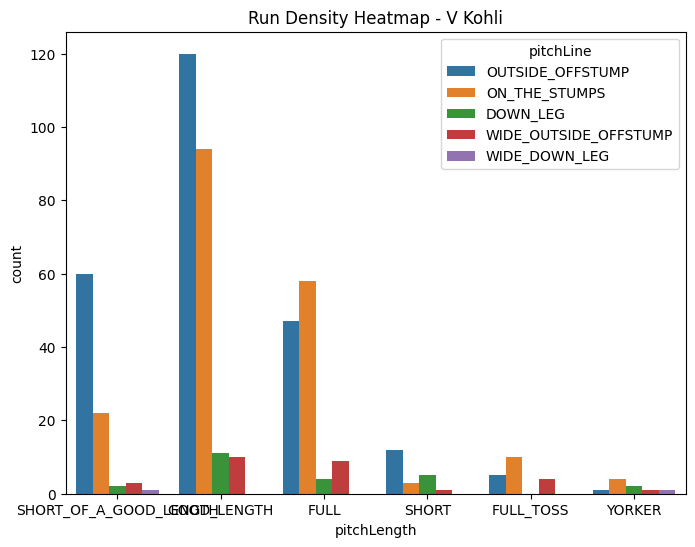

In [26]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=df[df['Full Name'] == 'Virat Kohli'],
    x='pitchLength', hue='pitchLine'
)
plt.title("Run Density Heatmap - V Kohli")
plt.show()

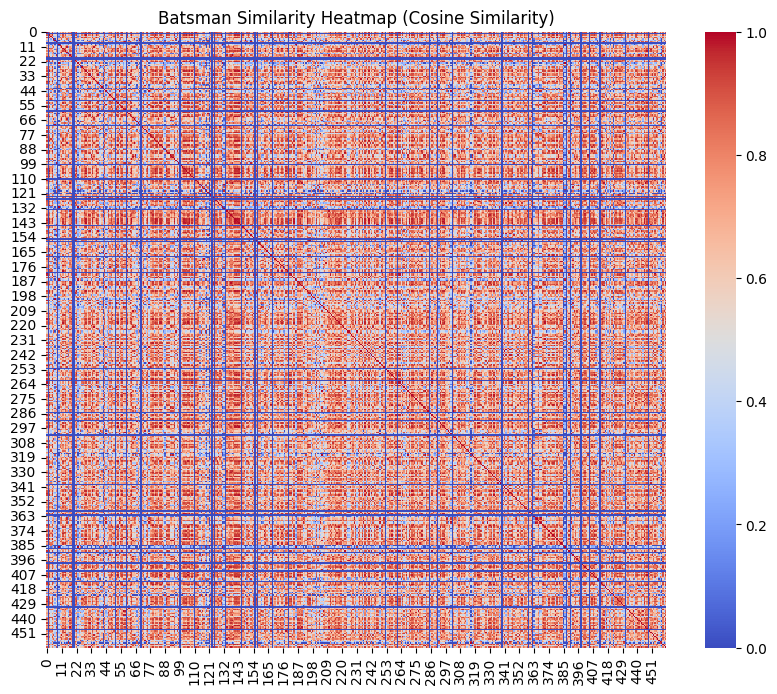

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, cmap="coolwarm")
plt.title("Batsman Similarity Heatmap (Cosine Similarity)")
plt.show()

In [28]:
batsman_metrics_overall.to_csv(r"C:\Users\yaswa\OneDrive\Desktop\artificial intelligence project\data\batsman_profiles.csv", index=False)
similar_df.to_csv(r"C:\Users\yaswa\OneDrive\Desktop\artificial intelligence project\data\batsman_similarity.csv")


C:\Users\yaswa\AppData\Local\Temp\ipykernel_14544\3754977388.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_batsmen, x='Full Name', y='Strike_Rate', palette='coolwarm')


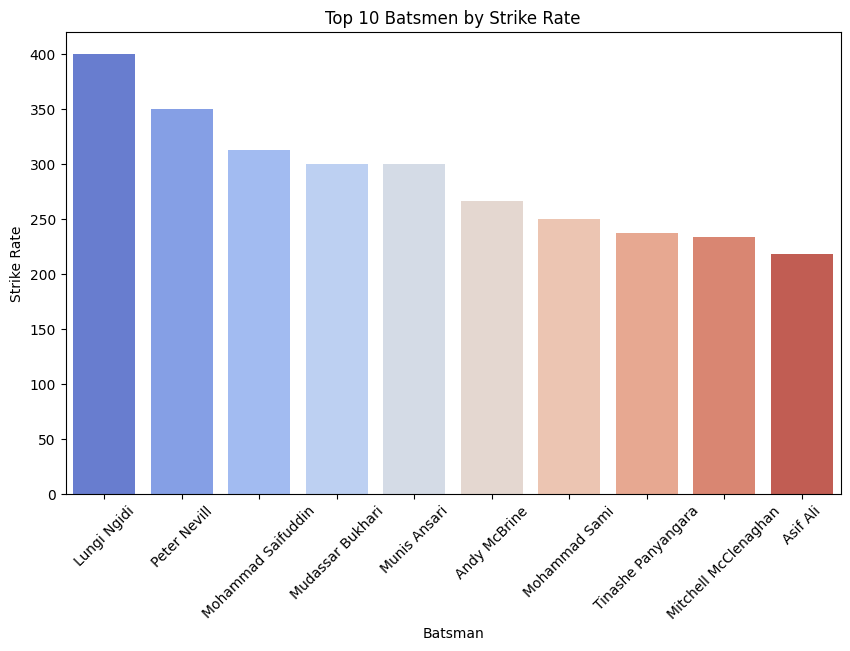

In [29]:
top_batsmen = batsman_metrics_overall.sort_values(by='Strike_Rate', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_batsmen, x='Full Name', y='Strike_Rate', palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Top 10 Batsmen by Strike Rate')
plt.xlabel('Batsman')
plt.ylabel('Strike Rate')
plt.show()

C:\Users\yaswa\AppData\Local\Temp\ipykernel_14544\1621249412.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_batsmen1, x='Full Name', y='Average', palette='viridis')


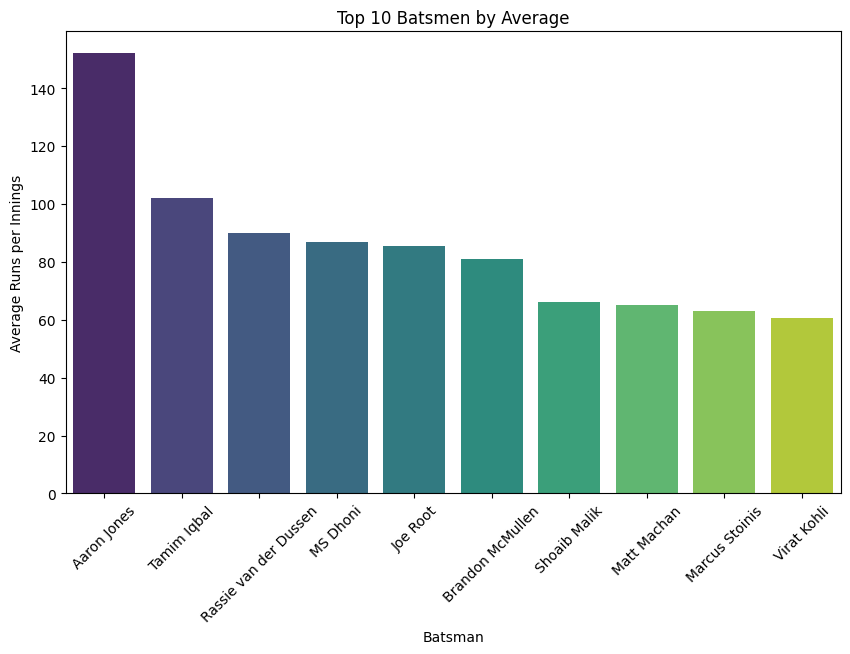

In [30]:
batsman_metrics_overall1=batsman_metrics_overall[batsman_metrics_overall['Average']!=np.inf]
top_batsmen1=batsman_metrics_overall1.sort_values(by='Average', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_batsmen1, x='Full Name', y='Average', palette='viridis')
plt.xticks(rotation=45)
plt.title('Top 10 Batsmen by Average')
plt.xlabel('Batsman')
plt.ylabel('Average Runs per Innings')
plt.show()

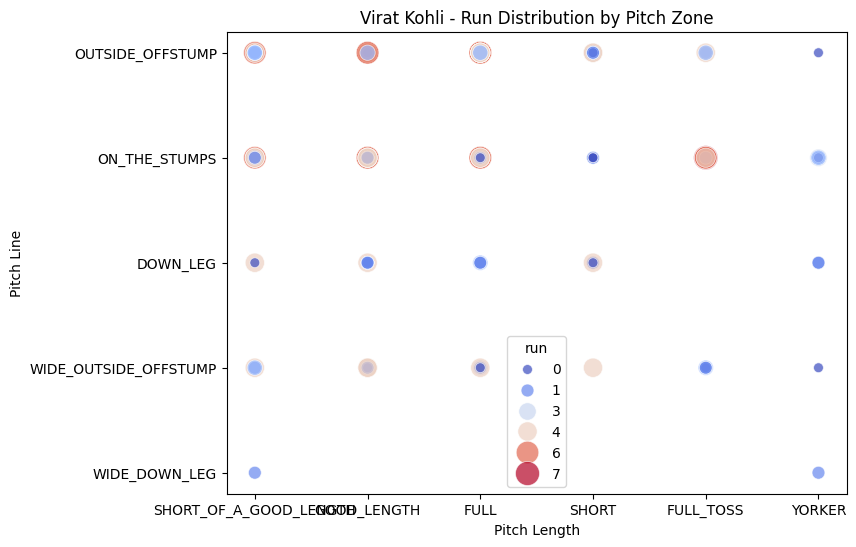

In [31]:
kohli_data = df[df['Full Name'] == 'Virat Kohli']

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=kohli_data,
    x='pitchLength', y='pitchLine',
    size='run', hue='run', palette='coolwarm', alpha=0.7, sizes=(50, 300)
)
plt.title("Virat Kohli - Run Distribution by Pitch Zone")
plt.xlabel("Pitch Length")
plt.ylabel("Pitch Line")
plt.show()
